In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
file_path = '/kaggle/input/datasets/imtkaggleteam/diabetes/diabetes.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

In [ ]:
print(f"Dataset Shape: {df.shape}")
print("\nData Types and Missing Values:")
df.info()

In [ ]:
df.describe().T

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', palette='Set2')
plt.title('Distribution of Diabetes Outcomes (0 = No, 1 = Yes)')
plt.show()

print(df['Outcome'].value_counts(normalize=True) * 100)

In [6]:
import numpy as np
import pandas as pd

# 1. Reload data
file_path = '/kaggle/input/datasets/imtkaggleteam/diabetes/diabetes.csv'
df = pd.read_csv(file_path)

# 2. Drop rows where our target indicator 'glyhb' is missing
df = df.dropna(subset=['glyhb'])

# 3. Create the 'Outcome' target column (1 for Diabetic, 0 for Non-Diabetic)
df['Outcome'] = (df['glyhb'] >= 6.5).astype(int)

# 4. Calculate BMI from weight (lbs) and height (inches)
# Formula: (weight / height^2) * 703
df['BMI'] = (df['weight'] / (df['height'] ** 2)) * 703

# 5. Identify columns where a 0 doesn't make sense and check for missing values
clinical_columns = ['chol', 'stab.glu', 'hdl', 'ratio', 'bp.1s', 'bp.1d', 'BMI']
print("Missing values per column before imputation:")
print(df[clinical_columns].isnull().sum())

# 6. Impute missing values using the median of each column grouped by Outcome
for col in clinical_columns:
    df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

print("\nMissing values after imputation:", df[clinical_columns].isnull().sum().sum())

Missing values per column before imputation:
chol        1
stab.glu    0
hdl         1
ratio       1
bp.1s       5
bp.1d       5
BMI         6
dtype: int64

Missing values after imputation: 0


/tmp/ipykernel_58/4083332056.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='ratio', ax=axes[1], palette='pastel')


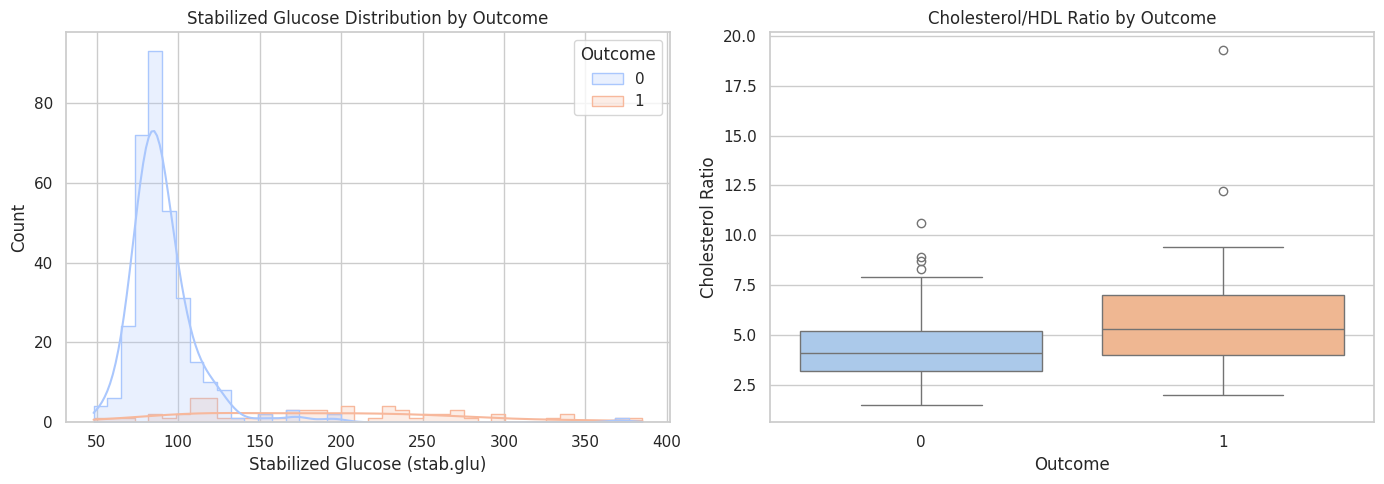

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Glucose distribution
sns.histplot(data=df, x='stab.glu', hue='Outcome', kde=True, element='step', ax=axes[0], palette='coolwarm')
axes[0].set_title('Stabilized Glucose Distribution by Outcome')
axes[0].set_xlabel('Stabilized Glucose (stab.glu)')

# Cholesterol ratio boxplot
sns.boxplot(data=df, x='Outcome', y='ratio', ax=axes[1], palette='pastel')
axes[1].set_title('Cholesterol/HDL Ratio by Outcome')
axes[1].set_ylabel('Cholesterol Ratio')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Drop tracking columns and the source column for our target
X = df.drop(columns=['id', 'location', 'glyhb', 'Outcome'])
y = df['Outcome']

# Convert categorical text columns into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['gender', 'frame'], drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handle any remaining NaN values that might be in unhandled columns
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median()) # Fill test with train median to avoid data leakage

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = rf_model.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 91.03%

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        65
           1       0.80      0.62      0.70        13

    accuracy                           0.91        78
   macro avg       0.86      0.79      0.82        78
weighted avg       0.91      0.91      0.91        78



/tmp/ipykernel_58/3497311176.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


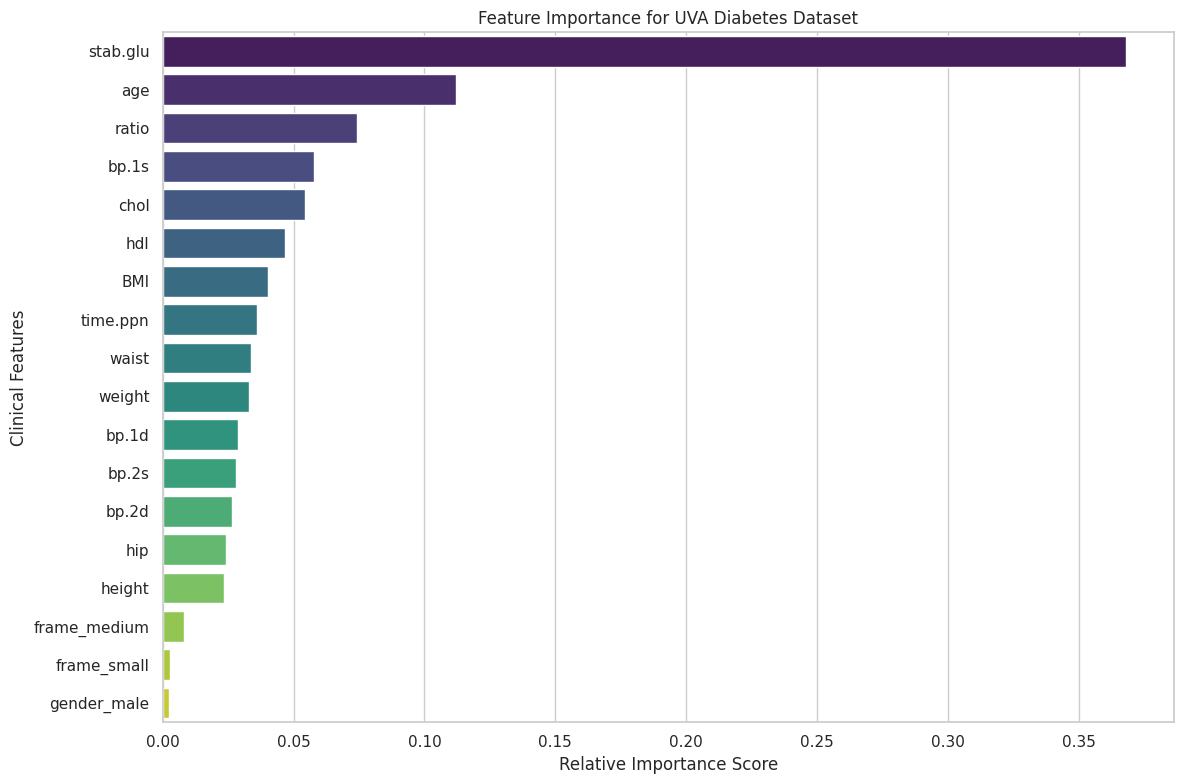

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from our trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# Plot the features
plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title('Feature Importance for UVA Diabetes Dataset')
plt.xlabel('Relative Importance Score')
plt.ylabel('Clinical Features')
plt.tight_layout()
plt.show()

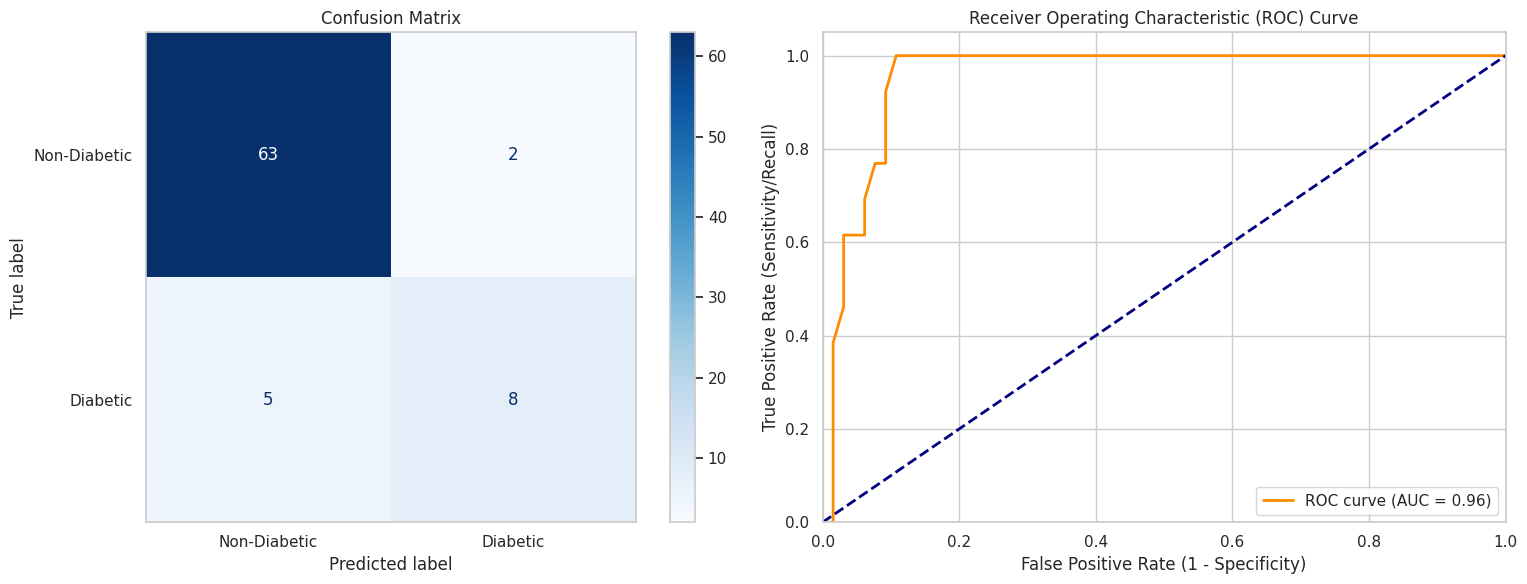

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 7.1 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic', 'Diabetic'])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Confusion Matrix on the first axis
disp.plot(cmap='Blues', ax=ax[0], values_format='d')
ax[0].set_title('Confusion Matrix')
ax[0].grid(False) # Turn off background grid lines for clarity

# 7.2 ROC Curve
# Get predicted probabilities for the positive class (Diabetes)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve on the second axis
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[1].set_ylabel('True Positive Rate (Sensitivity/Recall)')
ax[1].set_title('Receiver Operating Characteristic (ROC) Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize a new Random Forest model
rf_base = RandomForestClassifier(random_state=42)

# Set up the Grid Search with 5-fold cross-validation
# We score based on 'recall' to prioritize catching positive diabetes cases
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=5, scoring='recall', n_jobs=-1, verbose=1)

# Fit the grid search to the data
grid_search.fit(X_train_scaled, y_train)

# Output the best parameters found
print("Best Hyperparameters Found:")
print(grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters Found:
{'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [12]:
# Extract the best model
best_rf_model = grid_search.best_estimator_

# Predict on the test set
y_tuned_pred = best_rf_model.predict(X_test_scaled)

# Print evaluation metrics
print(f"Tuned Model Accuracy: {accuracy_score(y_test, y_tuned_pred):.2%}\n")
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_tuned_pred))

Tuned Model Accuracy: 91.03%

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        65
           1       0.80      0.62      0.70        13

    accuracy                           0.91        78
   macro avg       0.86      0.79      0.82        78
weighted avg       0.91      0.91      0.91        78



In [13]:
import joblib

# Save the trained scaler and the best model to disk
joblib.dump(scaler, 'diabetes_scaler.pkl')
joblib.dump(best_rf_model, 'tuned_diabetes_model.pkl')

print("Scaler and Model successfully saved as .pkl files!")

Scaler and Model successfully saved as .pkl files!


In [14]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

# 11.1 Initialize the models
log_reg = LogisticRegression(random_state=42, max_iter=1000)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

# 11.2 Train the models
log_reg.fit(X_train_scaled, y_train)
xgb_model.fit(X_train_scaled, y_train)

# 11.3 Generate predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Probabilities for AUC calculation
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [16]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

# 1. Gather all metrics into a dictionary
metrics_summary = {
    'Model': ['Tuned Random Forest', 'Logistic Regression', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_tuned_pred),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Recall (Diabetes Catches)': [
        recall_score(y_test, y_tuned_pred),
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC Score': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}

# 2. Convert to DataFrame
df_comparison = pd.DataFrame(metrics_summary)

# 3. Round to 3 decimal places explicitly and display as markdown
# This avoids the tabulate 'float_fmt' keyword error entirely
print(df_comparison.round(3).to_markdown(index=False))

| Model               |   Accuracy |   Recall (Diabetes Catches) |   ROC-AUC Score |
|:--------------------|-----------:|----------------------------:|----------------:|
| Tuned Random Forest |      0.91  |                       0.615 |           0.956 |
| Logistic Regression |      0.897 |                       0.538 |           0.929 |
| XGBoost             |      0.923 |                       0.692 |           0.955 |


In [17]:
def predict_patient_diabetes(patient_data, model, scaler, training_columns):
    """
    Takes raw patient data, preprocesses it, and returns a diabetes risk prediction.
    """
    # 1. Convert the dictionary into a DataFrame
    patient_df = pd.DataFrame([patient_data])
    
    # 2. Replicate Feature Engineering: Calculate BMI
    patient_df['BMI'] = (patient_df['weight'] / (patient_df['height'] ** 2)) * 703
    
    # 3. Replicate Categorical Encoding
    patient_df = pd.get_dummies(patient_df, columns=['gender', 'frame'])
    
    # 4. Align columns with the original training features (X.columns)
    # This automatically adds missing dummy columns as 0 and drops unneeded ones
    patient_df = patient_df.reindex(columns=training_columns, fill_value=0)
    
    # 5. Scale the features using the trained scaler
    patient_scaled = scaler.transform(patient_df)
    
    # 6. Generate Prediction and Probability
    risk_prediction = model.predict(patient_scaled)[0]
    risk_probability = model.predict_proba(patient_scaled)[0][1]
    
    return risk_prediction, risk_probability

In [23]:
import pandas as pd
import numpy as np

# 1. Define the inference pipeline function cleanly
def predict_patient_diabetes(patient_data, model, scaler, training_columns):
    # Convert the dictionary into a DataFrame
    patient_df = pd.DataFrame([patient_data])
    
    # Feature Engineering: Calculate BMI
    patient_df['BMI'] = (patient_df['weight'] / (patient_df['height'] ** 2)) * 703
    
    # Categorical Encoding
    patient_df = pd.get_dummies(patient_df, columns=['gender', 'frame'])
    
    # Align columns with the original training features
    patient_df = patient_df.reindex(columns=training_columns, fill_value=0)
    
    # Scale features
    patient_scaled = scaler.transform(patient_df)
    
    # Generate Prediction and Probability
    risk_prediction = model.predict(patient_scaled)[0]
    risk_probability = model.predict_proba(patient_scaled)[0][1]
    
    return risk_prediction, risk_probability


# 2. Set up the input variables (pulling from your active session)
training_features = X.columns.tolist()

# Patient A Profile
patient_a = {
    'chol': 180, 'stab.glu': 85, 'hdl': 55, 'ratio': 3.2, 'age': 28,
    'gender': 'female', 'height': 65, 'weight': 130, 'frame': 'medium',
    'bp.1s': 115, 'bp.1d': 75, 'bp.2s': 112, 'bp.2d': 74,
    'waist': 28, 'hip': 36, 'time.ppn': 120
}

# Patient B Profile
patient_b = {
    'chol': 265, 'stab.glu': 210, 'hdl': 31, 'ratio': 8.5, 'age': 54,
    'gender': 'male', 'height': 70, 'weight': 240, 'frame': 'large',
    'bp.1s': 145, 'bp.1d': 92, 'bp.2s': 142, 'bp.2d': 90,
    'waist': 44, 'hip': 42, 'time.ppn': 90
}


# 3. Execute the loop and print clean string logs
for name, patient in [("Patient A", patient_a), ("Patient B", patient_b)]:
    prediction, probability = predict_patient_diabetes(patient, best_rf_model, scaler, training_features)
    
    status = "DIABETIC RISK DETECTED" if prediction == 1 else "LOW RISK"
    print(f"--- {name} Results ---")
    print(f"Status: {status}")
    print(f"Confidence/Probability Score: {probability:.1%}\n")

--- Patient A Results ---
Status: LOW RISK
Confidence/Probability Score: 0.0%

--- Patient B Results ---
Status: DIABETIC RISK DETECTED
Confidence/Probability Score: 72.0%



In [24]:
# 1. Create a copy of the original unscaled test data
analysis_df = X_test.copy()
analysis_df['True_Outcome'] = y_test
analysis_df['Predicted_Outcome'] = y_tuned_pred

# 2. Identify False Negatives and False Positives
# False Negatives: Patient has diabetes (1), but model predicted healthy (0)
false_negatives = analysis_df[(analysis_df['True_Outcome'] == 1) & (analysis_df['Predicted_Outcome'] == 0)]

# False Positives: Patient is healthy (0), but model predicted diabetes (1)
false_positives = analysis_df[(analysis_df['True_Outcome'] == 0) & (analysis_df['Predicted_Outcome'] == 1)]

# True Positives & True Negatives (Correct predictions)
correct_predictions = analysis_df[analysis_df['True_Outcome'] == analysis_df['Predicted_Outcome']]

print(f"Total Test Cases: {len(analysis_df)}")
print(f"Number of False Negatives (Missed Patients): {len(false_negatives)}")
print(f"Number of False Positives (False Alarms): {len(false_positives)}\n")

Total Test Cases: 78
Number of False Negatives (Missed Patients): 5
Number of False Positives (False Alarms): 2



In [25]:
# Select core clinical indicators to analyze
core_metrics = ['stab.glu', 'BMI', 'age', 'ratio', 'bp.1s']

print("--- Average Metrics Comparison ---")
comparison_metrics = pd.DataFrame({
    'Correct Predictions': correct_predictions[core_metrics].mean(),
    'False Negatives (Missed)': false_negatives[core_metrics].mean(),
    'False Positives (False Alarms)': false_positives[core_metrics].mean()
})

print(comparison_metrics.round(2).to_markdown())

--- Average Metrics Comparison ---
|          |   Correct Predictions |   False Negatives (Missed) |   False Positives (False Alarms) |
|:---------|----------------------:|---------------------------:|---------------------------------:|
| stab.glu |                101.69 |                     118    |                           271    |
| BMI      |                 28.16 |                      32.52 |                            26.25 |
| age      |                 50.14 |                      50.8  |                            73    |
| ratio    |                  4.39 |                       5.46 |                             4.9  |
| bp.1s    |                135.92 |                     154    |                           134    |


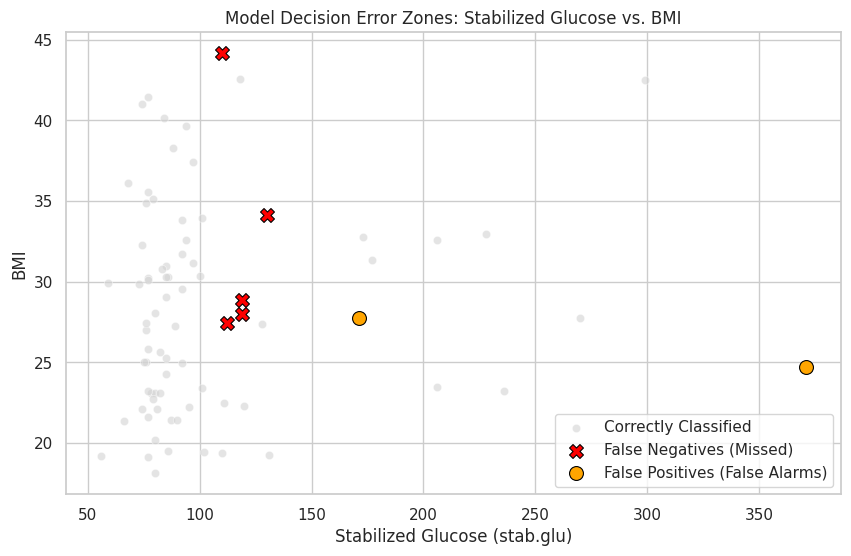

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot correct predictions in gray
sns.scatterplot(data=correct_predictions, x='stab.glu', y='BMI', 
                color='lightgray', alpha=0.6, label='Correctly Classified')

# Highlight False Negatives in bright red
if not false_negatives.empty:
    sns.scatterplot(data=false_negatives, x='stab.glu', y='BMI', 
                    color='red', s=100, edgecolor='black', marker='X', label='False Negatives (Missed)')

# Highlight False Positives in bright orange
if not false_positives.empty:
    sns.scatterplot(data=false_positives, x='stab.glu', y='BMI', 
                    color='orange', s=100, edgecolor='black', marker='o', label='False Positives (False Alarms)')

plt.title('Model Decision Error Zones: Stabilized Glucose vs. BMI')
plt.xlabel('Stabilized Glucose (stab.glu)')
plt.ylabel('BMI')
plt.legend()
plt.show()

In [27]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Check the distribution before SMOTE
print(f"Class distribution before SMOTE: {Counter(y_train)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample only the scaled training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Check the distribution after SMOTE
print(f"Class distribution after SMOTE: {Counter(y_train_balanced)}")

Class distribution before SMOTE: Counter({0: 260, 1: 52})
Class distribution after SMOTE: Counter({0: 260, 1: 260})


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the model using the best parameters from your prior grid search
# dynamically unpacking them with **
balanced_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)

# Train on the balanced data
balanced_rf.fit(X_train_balanced, y_train_balanced)

# Predict on the ORIGINAL, untouched, un-balanced test set
y_balanced_pred = balanced_rf.predict(X_test_scaled)

# Print final performance metrics
print(f"Balanced Model Accuracy: {accuracy_score(y_test, y_balanced_pred):.2%}\n")
print("Classification Report After SMOTE Balancing:")
print(classification_report(y_test, y_balanced_pred))

Balanced Model Accuracy: 92.31%

Classification Report After SMOTE Balancing:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        65
           1       0.73      0.85      0.79        13

    accuracy                           0.92        78
   macro avg       0.85      0.89      0.87        78
weighted avg       0.93      0.92      0.93        78



In [29]:
from sklearn.metrics import recall_score

baseline_recall = recall_score(y_test, y_pred)
balanced_recall = recall_score(y_test, y_balanced_pred)

print(f"Initial Baseline Recall: {baseline_recall:.1%}")
print(f"Post-SMOTE Balanced Recall: {balanced_recall:.1%}")
print(f"Net change in caught diabetes cases: {balanced_recall - baseline_recall:+.1%}")

Initial Baseline Recall: 61.5%
Post-SMOTE Balanced Recall: 84.6%
Net change in caught diabetes cases: +23.1%


In [30]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the SHAP Explainer specifically optimized for tree models
explainer = shap.TreeExplainer(balanced_rf)

# 2. Calculate SHAP values for your scaled test features
shap_values = explainer.shap_values(X_test_scaled)

# 3. Handle package version variations safely
# Binary classification models sometimes return a list of two arrays [class_0, class_1]
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]  # Focus entirely on class 1 (Diabetic risk)
else:
    shap_matrix = shap_values

<Figure size 1000x600 with 0 Axes>

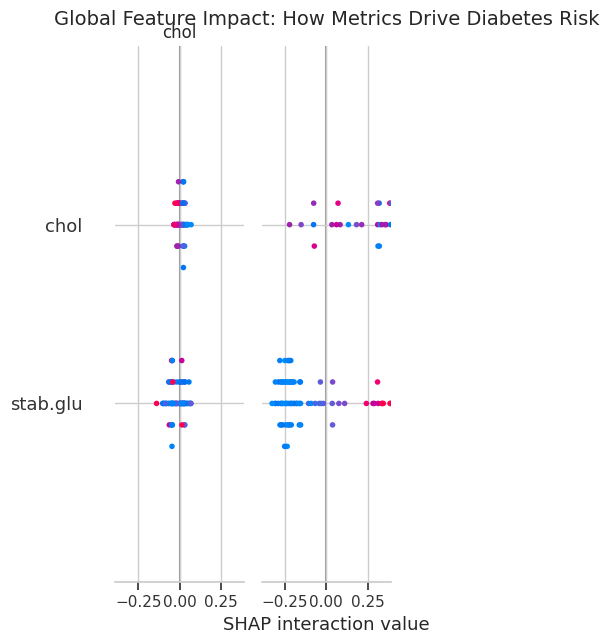

In [31]:
# Create a standard SHAP summary plot
plt.figure(figsize=(10, 6))

# Passing 'show=False' allows us to modify the plot with standard matplotlib commands safely
shap.summary_plot(shap_matrix, X_test, feature_names=X.columns, show=False)

plt.title("Global Feature Impact: How Metrics Drive Diabetes Risk", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

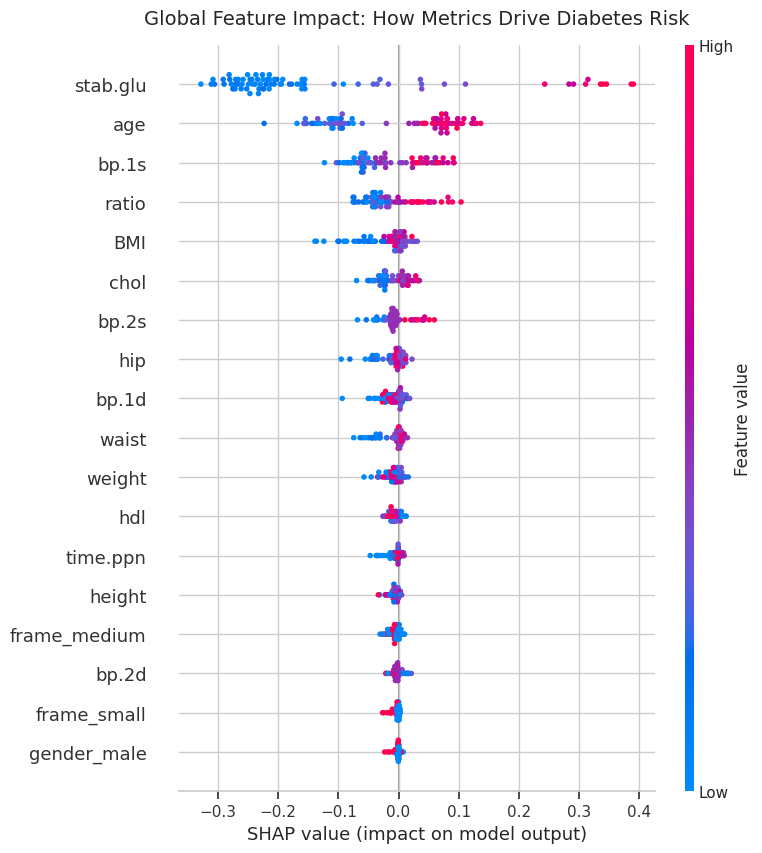

AttributeError: 'Pandas' object has no attribute 'Raw_Value'

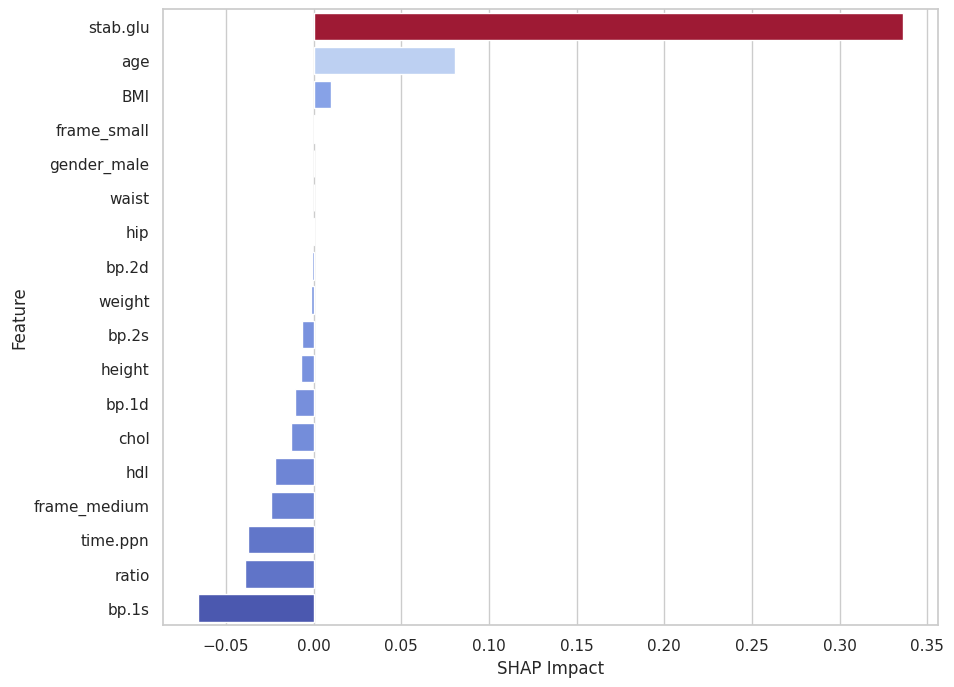

In [33]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Step 21: Robust SHAP Value Extraction
# ==========================================
explainer = shap.TreeExplainer(balanced_rf)
shap_values = explainer.shap_values(X_test_scaled)

# Force the shap_matrix to be a 2D array of shape (samples, features) for Class 1 (Diabetic)
if isinstance(shap_values, list):
    # Older SHAP versions return a list of arrays per class
    shap_matrix = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # Newer SHAP versions return a 3D array: (samples, features, classes)
    shap_matrix = shap_values[:, :, 1]
else:
    # Fallback default for standard 2D arrays
    shap_matrix = shap_values

# ==========================================
# Step 22: Global Interpretability Plot
# ==========================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_matrix, X_test, feature_names=X.columns, show=False)
plt.title("Global Feature Impact: How Metrics Drive Diabetes Risk", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# ==========================================
# Step 23: Local Interpretability Plot (FIXED)
# ==========================================
patient_index = 0
raw_patient_data = X_test.iloc[patient_index]

# Pull the single patient's SHAP array and flatten it completely to 1-dimension
patient_shap_values = np.ravel(shap_matrix[patient_index])

# Build the DataFrame now that dimensions are strictly 1D
local_impact_df = pd.DataFrame({
    'Feature': X.columns,
    'Raw Value': raw_patient_data.values,
    'SHAP Impact': patient_shap_values
}).sort_values(by='SHAP Impact', ascending=False)

# Render the visualization safely
plt.figure(figsize=(10, 8))
sns.barplot(
    data=local_impact_df, 
    x='SHAP Impact', 
    y='Feature', 
    palette='coolwarm', 
    hue='SHAP Impact', 
    legend=False
)

# Overlay the patient's actual medical values as text labels
for idx, row in enumerate(local_impact_df.itertuples()):
    val_str = f"{row.Raw_Value:.1f}" if row.Raw_Value >= 1 else f"{row.Raw_Value:.3f}"
    plt.text(row.SHAP_Impact, idx, f" (Value: {val_str})", 
             va='center', ha='left' if row.SHAP_Impact >= 0 else 'right', fontsize=9)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title(f"Patient #{patient_index} Local Diagnosis Breakdown", fontsize=14, pad=15)
plt.xlabel("SHAP Impact Score (Positive pushes toward Diabetes | Negative pulls toward Healthy)")
plt.ylabel("Clinical Metrics")
plt.tight_layout()
plt.show()